# 그린 정리, FTC의 일반화, 오일러 정리 (뉴진수 13강)-13강 3기 13강

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x, y, t = sp.symbols("x y t", real=True)

## 2. FTC의 경계 관점
1변수 미적분학의 기본정리 $\int_a^b f'(x)\,dx = f(b)-f(a)$ 를 SymPy로 다시 확인합니다.
왼쪽은 구간 내부 전체의 적분, 오른쪽은 경계 두 점에서의 값 차이입니다.

In [2]:
f = sp.sin(x) + x**3 - 2 * x
a_, b_ = sp.Integer(0), sp.Integer(2)
lhs = sp.integrate(sp.diff(f, x), (x, a_, b_))
rhs = f.subs(x, b_) - f.subs(x, a_)
print("f(x)            =", f)
print("∫_0^2 f'(x) dx  =", sp.simplify(lhs))
print("f(2) - f(0)     =", sp.simplify(rhs))
print("두 값이 같은가?  =", sp.simplify(lhs - rhs) == 0)

f(x)            = x**3 - 2*x + sin(x)
∫_0^2 f'(x) dx  = sin(2) + 4
f(2) - f(0)     = sin(2) + 4
두 값이 같은가?  = True


## 5. 내부 회전과 경계 선적분 (그린 정리)
$$\oint_C M\,dx + N\,dy = \iint_R\left(\frac{\partial N}{\partial x}-\frac{\partial M}{\partial y}\right)dx\,dy$$
구체적인 벡터장 $\mathbf F=(M,N)=(-y,\;x)$ 와 단위원 $C$ 위에서
**경계 선적분(좌변)** 과 **내부 회전 면적분(우변)** 이 같음을 SymPy로 검산합니다.
이 벡터장의 2차원 회전은 $N_x - M_y = 1 - (-1) = 2$ 로 상수이므로, 우변은 $2\cdot(\text{넓이})=2\pi$ 가 됩니다.

In [3]:
M, N = -y, x
curl2d = sp.diff(N, x) - sp.diff(M, y)
print("F = (M, N) =", (M, N))
print("2D curl  N_x - M_y =", curl2d)

# 우변: 단위원 내부 R 에서 회전을 면적분 (극좌표)
r, th = sp.symbols("r theta", positive=True)
area_integral = sp.integrate(
    sp.integrate(curl2d.subs({x: r * sp.cos(th), y: r * sp.sin(th)}) * r, (r, 0, 1)),
    (th, 0, 2 * sp.pi),
)
print("우변 ∬_R (N_x - M_y) dA =", area_integral)

# 좌변: 경계 C 를 r(t)=(cos t, sin t) 로 매개화한 선적분 ∮ M dx + N dy
xt, yt = sp.cos(t), sp.sin(t)
integrand = M.subs({x: xt, y: yt}) * sp.diff(xt, t) + N.subs({x: xt, y: yt}) * sp.diff(yt, t)
line_integral = sp.integrate(sp.simplify(integrand), (t, 0, 2 * sp.pi))
print("좌변 ∮_C M dx + N dy   =", line_integral)
print("그린 정리 성립?         =", sp.simplify(area_integral - line_integral) == 0)

F = (M, N) = (-y, x)
2D curl  N_x - M_y = 2
우변 ∬_R (N_x - M_y) dA = 2*pi
좌변 ∮_C M dx + N dy   = 2*pi
그린 정리 성립?         = True


### 한 단계 더: 회전이 자명하지 않은 벡터장
$\mathbf F=(M,N)=(x y,\; x^2)$ 에서는 $N_x-M_y = 2x - x = x$ 로 위치마다 회전이 다릅니다.
한 변 길이 1인 정사각형 $[0,1]\times[0,1]$ 의 경계와 내부에서 다시 검산합니다.

In [4]:
M2, N2 = x * y, x**2
curl2 = sp.diff(N2, x) - sp.diff(M2, y)
rhs2 = sp.integrate(sp.integrate(curl2, (x, 0, 1)), (y, 0, 1))

# 정사각형 경계 4변을 반시계 방향으로 선적분
def seg(M_, N_, px, py):
    g = M_.subs({x: px, y: py}) * sp.diff(px, t) + N_.subs({x: px, y: py}) * sp.diff(py, t)
    return sp.integrate(g, (t, 0, 1))

lhs2 = (
    seg(M2, N2, t, sp.Integer(0))          # (0,0)->(1,0)
    + seg(M2, N2, sp.Integer(1), t)        # (1,0)->(1,1)
    + seg(M2, N2, 1 - t, sp.Integer(1))    # (1,1)->(0,1)
    + seg(M2, N2, sp.Integer(0), 1 - t)    # (0,1)->(0,0)
)
print("curl  N_x - M_y =", curl2)
print("우변 ∬_R curl dA =", rhs2)
print("좌변 ∮_C F·dr    =", sp.simplify(lhs2))
print("그린 정리 성립?   =", sp.simplify(rhs2 - lhs2) == 0)

curl  N_x - M_y = x
우변 ∬_R curl dA = 1/2
좌변 ∮_C F·dr    = 1/2
그린 정리 성립?   = True


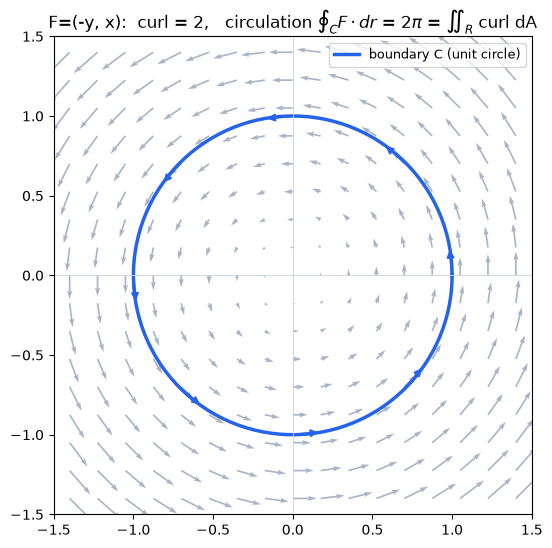

In [5]:
# 벡터장 F=(-y,x) 와 경계 순환 그림 (모든 라벨은 영어)
fig, ax = plt.subplots(figsize=(5.6, 5.6))
gx, gy = np.meshgrid(np.linspace(-1.4, 1.4, 17), np.linspace(-1.4, 1.4, 17))
U, V = -gy, gx
ax.quiver(gx, gy, U, V, color="#94a3b8", alpha=0.8, scale=28)
ang = np.linspace(0, 2 * np.pi, 240)
ax.plot(np.cos(ang), np.sin(ang), color="#2563eb", lw=2.5, label="boundary C (unit circle)")
# 반시계 방향 화살표 몇 개
for a0 in np.linspace(0, 2 * np.pi, 8, endpoint=False):
    ax.annotate("", xy=(np.cos(a0 + 0.18), np.sin(a0 + 0.18)),
                xytext=(np.cos(a0), np.sin(a0)),
                arrowprops=dict(arrowstyle="-|>", color="#2563eb", lw=1.6))
ax.set_title("F=(-y, x):  curl = 2,   circulation $\\oint_C F\\cdot dr$ = 2$\\pi$ = $\\iint_R$ curl dA")
ax.set_aspect("equal"); ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.axhline(0, color="#d0d7de", lw=.7); ax.axvline(0, color="#d0d7de", lw=.7)
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

## 7. 회전이 0이면 보존장인가
소용돌이 벡터장 $\mathbf F=\left(\dfrac{-y}{x^2+y^2},\;\dfrac{x}{x^2+y^2}\right)$ 는
원점을 제외한 모든 점에서 2차원 회전이 $0$ 입니다. 그런데 원점을 둘러싼 폐곡선의 선적분은 $0$ 이 아니라 $2\pi$ 입니다.
"국소적으로 curl$=0$" 이라고 해서 보존장이 되는 것은 아니라는 것 — 영역의 **구멍(특이점)** 이 핵심임을 보여줍니다.

In [6]:
Mv = -y / (x**2 + y**2)
Nv = x / (x**2 + y**2)
curl_v = sp.simplify(sp.diff(Nv, x) - sp.diff(Mv, y))
print("vortex field curl (원점 제외) =", curl_v)

# 원점을 둘러싼 단위원 위에서의 선적분
xt, yt = sp.cos(t), sp.sin(t)
g = Mv.subs({x: xt, y: yt}) * sp.diff(xt, t) + Nv.subs({x: xt, y: yt}) * sp.diff(yt, t)
loop = sp.integrate(sp.simplify(g), (t, 0, 2 * sp.pi))
print("원점을 감싸는 폐곡선 ∮ F·dr  =", loop, "  (≠ 0 — 보존장이 아님)")

vortex field curl (원점 제외) = 0
원점을 감싸는 폐곡선 ∮ F·dr  = 2*pi   (≠ 0 — 보존장이 아님)


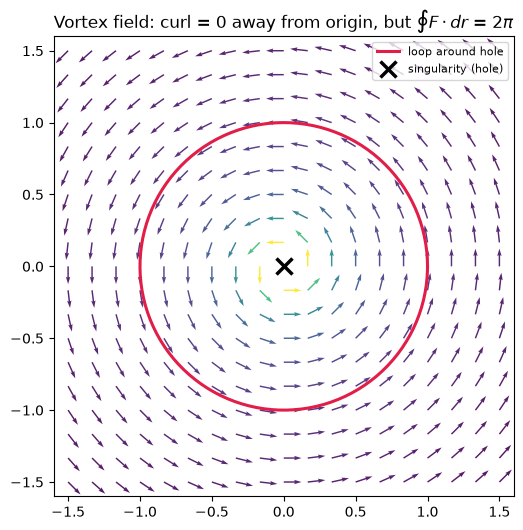

In [7]:
fig, ax = plt.subplots(figsize=(5.4, 5.4))
gx, gy = np.meshgrid(np.linspace(-1.5, 1.5, 19), np.linspace(-1.5, 1.5, 19))
den = gx**2 + gy**2
den[den < 1e-3] = np.nan
U, V = -gy / den, gx / den
sp_ = np.sqrt(U**2 + V**2)
ax.quiver(gx, gy, U / sp_, V / sp_, sp_, cmap="viridis", scale=26, alpha=0.9)
ang = np.linspace(0, 2 * np.pi, 240)
ax.plot(np.cos(ang), np.sin(ang), color="#e11d48", lw=2.2, label="loop around hole")
ax.plot(0, 0, "kx", ms=11, mew=2.5, label="singularity (hole)")
ax.set_title("Vortex field: curl = 0 away from origin, but $\\oint F\\cdot dr$ = 2$\\pi$")
ax.set_aspect("equal"); ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

## 10. 오일러 정리와 한계생산
$r$차 동차함수는 $q(\lambda L,\lambda K)=\lambda^r q(L,K)$ 를 만족하고, 오일러 정리는
$$L\,q_L + K\,q_K = r\,q(L,K)$$
입니다. 코브-더글러스형 $q(L,K)=A\,L^\alpha K^\beta$ 로 $L q_L+K q_K=(\alpha+\beta)q$ 임을 SymPy로 검산하고,
$\alpha+\beta=1$ 이면 1차 동차(규모수익불변)임을 확인합니다.

In [8]:
L, K, A, alpha, beta, lam = sp.symbols("L K A alpha beta lambda", positive=True)
q = A * L**alpha * K**beta

# 동차차수 확인: q(λL, λK) / q(L,K) = λ^(α+β)
ratio = sp.simplify(q.subs({L: lam * L, K: lam * K}) / q)
print("q(λL, λK) / q(L,K) =", ratio, "  ->  동차차수 r = α + β")

qL = sp.diff(q, L)
qK = sp.diff(q, K)
euler_lhs = sp.simplify(L * qL + K * qK)
euler_rhs = sp.simplify((alpha + beta) * q)
print("L q_L + K q_K      =", euler_lhs)
print("(α+β) q            =", euler_rhs)
print("오일러 정리 성립?    =", sp.simplify(euler_lhs - euler_rhs) == 0)

# 1차 동차 (규모수익불변)의 특수화: β = 1 - α
q1 = q.subs(beta, 1 - alpha)
print("\n1차 동차 (β=1−α) 일 때  L q_L + K q_K =",
      sp.simplify(L * sp.diff(q1, L) + K * sp.diff(q1, K)), " = q  (전체 산출량)")

q(λL, λK) / q(L,K) = lambda**(alpha + beta)   ->  동차차수 r = α + β
L q_L + K q_K      = A*K**beta*L**alpha*(alpha + beta)
(α+β) q            = A*K**beta*L**alpha*(alpha + beta)
오일러 정리 성립?    = True

1차 동차 (β=1−α) 일 때  L q_L + K q_K = A*K**(1 - alpha)*L**alpha  = q  (전체 산출량)


## 11. 왜 한계생산에 현재 투입량을 곱하는가 — 방향미분
$L q_L + K q_K$ 는 점 $(L,K)$ 에서 **원점 바깥으로 뻗는 스케일링 방향 $(L,K)$** 으로의 방향미분과 같습니다.
$g(s)=q\big((1+s)L,\,(1+s)K\big)$ 라 두면 $g'(0)=L q_L + K q_K$ 이고,
동차성에 의해 $g(s)=(1+s)^r q$ 이므로 $g'(0)=r\,q$ 로 정리됩니다.

In [9]:
s = sp.symbols("s", real=True)
qc = sp.Rational(1, 1) * L**sp.Rational(1, 3) * K**sp.Rational(2, 3)   # A=1, α=1/3, β=2/3 (r=1)
g = qc.subs({L: (1 + s) * L, K: (1 + s) * K})
gprime0 = sp.simplify(sp.diff(g, s).subs(s, 0))
direct = sp.simplify(L * sp.diff(qc, L) + K * sp.diff(qc, K))
print("q(L,K) = L^(1/3) K^(2/3)   (r = 1)")
print("g'(0)  [스케일링 방향미분] =", gprime0)
print("L q_L + K q_K              =", direct)
print("r·q  (= 1·q)              =", sp.simplify(qc))
print("세 값이 모두 같은가?        =", sp.simplify(gprime0 - direct) == 0 and sp.simplify(direct - qc) == 0)

q(L,K) = L^(1/3) K^(2/3)   (r = 1)
g'(0)  [스케일링 방향미분] = K**(2/3)*L**(1/3)
L q_L + K q_K              = K**(2/3)*L**(1/3)
r·q  (= 1·q)              = K**(2/3)*L**(1/3)
세 값이 모두 같은가?        = True


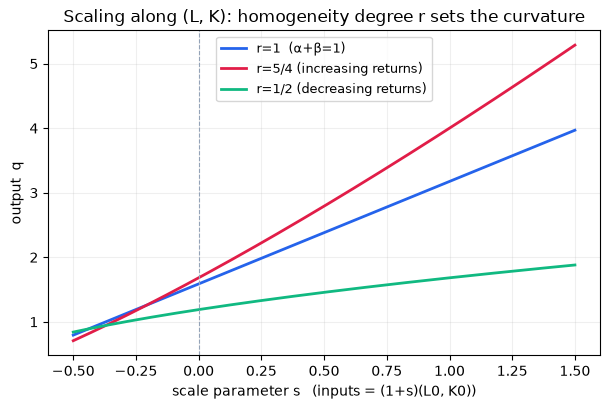

In [10]:
# 스케일링 직선 (1+s)(L0,K0) 을 따라 q 가 어떻게 변하는지 (r=1 이면 직선, r≠1 이면 곡선)
L0, K0 = 1.0, 2.0
ss = np.linspace(-0.5, 1.5, 200)
fig, ax = plt.subplots(figsize=(6.2, 4.2))
for (al, be), color, lab in [((1 / 3, 2 / 3), "#2563eb", "r=1  (α+β=1)"),
                             ((1 / 2, 3 / 4), "#e11d48", "r=5/4 (increasing returns)"),
                             ((1 / 4, 1 / 4), "#10b981", "r=1/2 (decreasing returns)")]:
    qv = ((1 + ss) * L0) ** al * ((1 + ss) * K0) ** be
    ax.plot(ss, qv, color=color, lw=2, label=lab)
ax.axvline(0, color="#94a3b8", lw=.8, ls="--")
ax.set_xlabel("scale parameter s   (inputs = (1+s)(L0, K0))")
ax.set_ylabel("output  q")
ax.set_title("Scaling along (L, K): homogeneity degree r sets the curvature")
ax.legend(fontsize=9); ax.grid(alpha=.2)
fig.tight_layout()
plt.show()